In [4]:
import pandas as pd

df = pd.read_csv("KDDTrain+.txt", header=None)
df.shape, df.head()


((125973, 43),
    0    1         2   3    4     5   6   7   8   9   ...    33    34    35  \
 0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...  0.17  0.03  0.17   
 1   0  udp     other  SF  146     0   0   0   0   0  ...  0.00  0.60  0.88   
 2   0  tcp   private  S0    0     0   0   0   0   0  ...  0.10  0.05  0.00   
 3   0  tcp      http  SF  232  8153   0   0   0   0  ...  1.00  0.00  0.03   
 4   0  tcp      http  SF  199   420   0   0   0   0  ...  1.00  0.00  0.00   
 
      36    37    38    39    40       41  42  
 0  0.00  0.00  0.00  0.05  0.00   normal  20  
 1  0.00  0.00  0.00  0.00  0.00   normal  15  
 2  0.00  1.00  1.00  0.00  0.00  neptune  19  
 3  0.04  0.03  0.01  0.00  0.01   normal  21  
 4  0.00  0.00  0.00  0.00  0.00   normal  21  
 
 [5 rows x 43 columns])

In [5]:
# Official 41 NSL-KDD feature names
feature_names = [
"duration","protocol_type","service","flag","src_bytes","dst_bytes",
"land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
"num_compromised","root_shell","su_attempted","num_root","num_file_creations",
"num_shells","num_access_files","num_outbound_cmds","is_host_login",
"is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
"rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
"srv_diff_host_rate","dst_host_count","dst_host_srv_count",
"dst_host_same_srv_rate","dst_host_diff_srv_rate",
"dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
"dst_host_serror_rate","dst_host_srv_serror_rate",
"dst_host_rerror_rate","dst_host_srv_rerror_rate"
]

# Add the last 2 columns
feature_names += ["attack_type", "difficulty_level"]

# Assign names to dataframe
df.columns = feature_names

df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [6]:
# Mentor-provided attack category lists
dos_attacks = ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop',
               'apache2', 'mailbomb', 'processtable', 'udpstorm', 'worm',
               'buffer_overflow']

probe_attacks = ['satan', 'ipsweep', 'nmap', 'portsweep', 'mscan', 'saint']

r2l_attacks = ['guess_passwd', 'ftp_write', 'imap', 'phf', 'multihop',
               'warezmaster', 'warezclient', 'spy', 'xlock', 'xsnoop',
               'snmpgetattack', 'snmpguess', 'httptunnel', 'sendmail',
               'named']

u2r_attacks = ['rootkit', 'perl', 'loadmodule', 'ps', 'sqlattack']


# Function to map raw attack to category
def map_attack(label):
    label = label.strip().lower()
    if label in dos_attacks:
        return "DoS"
    elif label in probe_attacks:
        return "Probe"
    elif label in r2l_attacks:
        return "R2L"
    elif label in u2r_attacks:
        return "U2R"
    else:
        return "normal"

# Apply the mapping
df['attack_category'] = df['attack_type'].apply(map_attack)

# Display first few rows to verify
df[['attack_type', 'attack_category']].head(10)


,attack_type,attack_category
0,normal,normal
1,normal,normal
2,neptune,DoS
3,normal,normal
4,normal,normal
5,neptune,DoS
6,neptune,DoS
7,neptune,DoS
8,neptune,DoS
9,neptune,DoS


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [8]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty_level
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [9]:
df.isnull().sum()



,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [10]:
df.duplicated().sum()


np.int64(0)

In [11]:
df['protocol_type'].unique()
df['service'].unique()
df['flag'].unique()


array(['SF', 'S0', 'REJ', 'RSTR', 'SH', 'RSTO', 'S1', 'RSTOS0', 'S3',
       'S2', 'OTH'], dtype=object)

In [12]:
df = df.dropna()
df.shape


(125973, 44)

In [13]:
df = df.drop(columns=['num_outbound_cmds'])
df.shape


(125973, 43)

In [14]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['protocol_type'] = encoder.fit_transform(df['protocol_type'])
df['service'] = encoder.fit_transform(df['service'])
df['flag'] = encoder.fit_transform(df['flag'])

df[['protocol_type', 'service', 'flag']].head()


,protocol_type,service,flag
0,1,20,9
1,2,44,9
2,1,49,5
3,1,24,9
4,1,24,9


In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# All columns except the labels
numeric_cols = df.drop(columns=['attack_type', 'attack_category']).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [16]:
from sklearn.model_selection import train_test_split

# Features (everything except attack labels)
X = df.drop(columns=['attack_type', 'attack_category'])

# Target (what we want to predict)
y = df['attack_category']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((100778, 41), (25195, 41))

# Week 3: Feature Engineering and Selection

## Objective
The goal of this week is to identify the most important features for intrusion detection
and reduce redundancy using statistical and model-based techniques.

This notebook focuses on:
- Correlation analysis
- Feature importance analysis


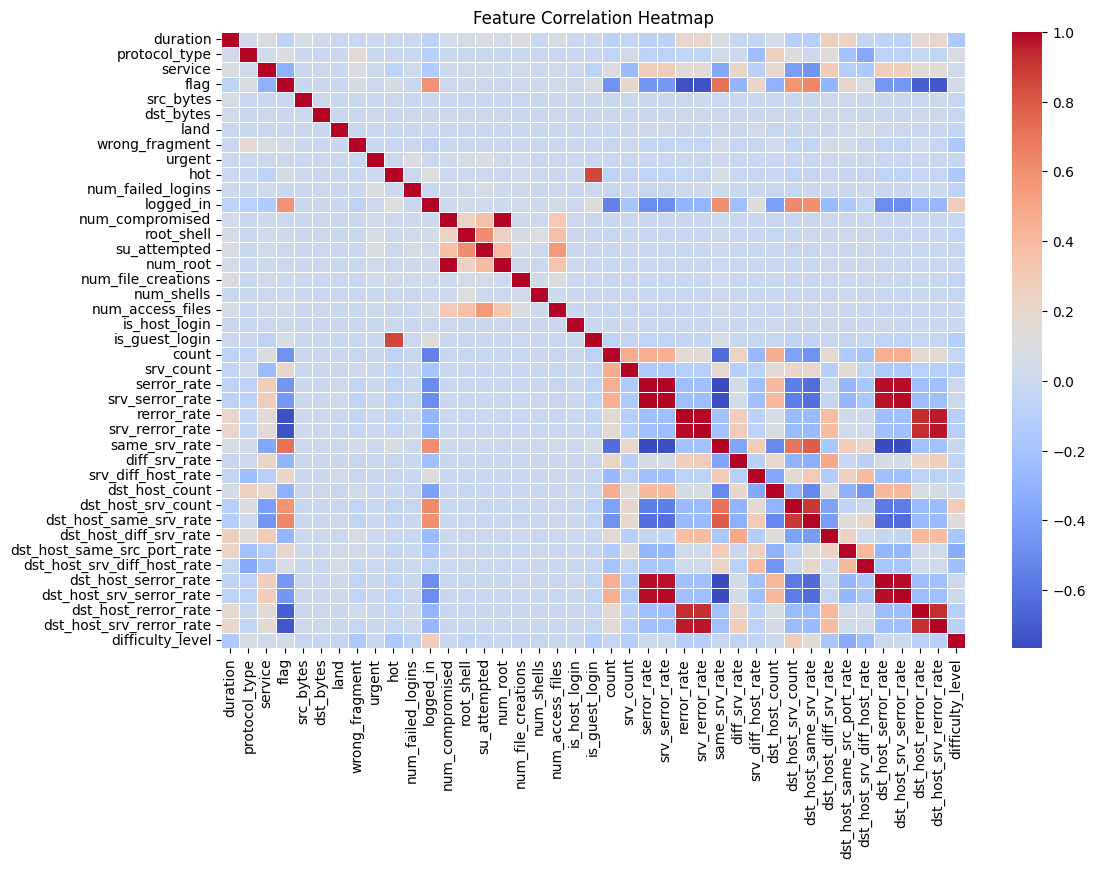

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# take only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# correlation matrix
corr = numeric_df.corr()

# plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


In [3]:
!ls


KDDTrain+.txt  sample_data


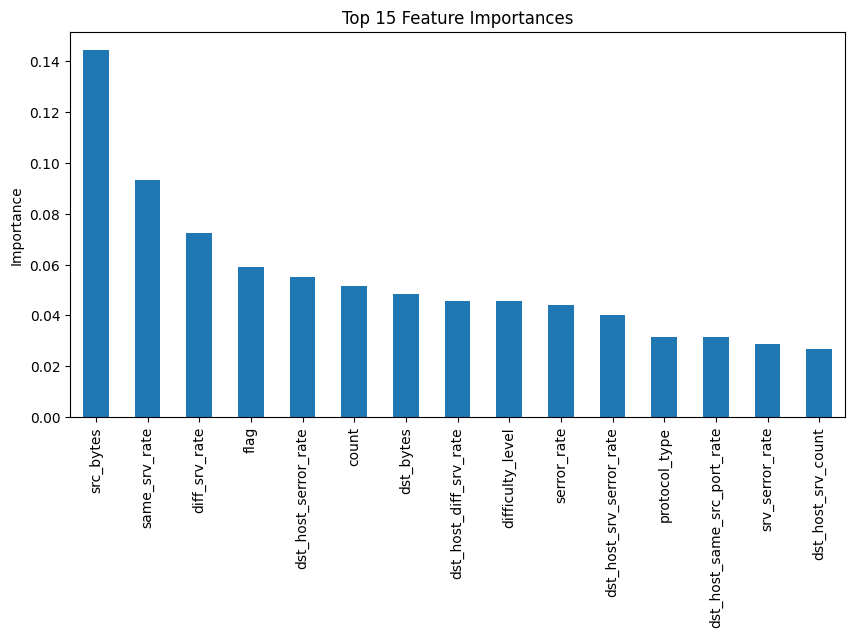

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(df['attack_category'])

# Features (drop labels)
X = df.drop(columns=['attack_type', 'attack_category'])

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature importance
importances = rf.feature_importances_
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Plot top 15 features
feature_importance.head(15).plot(kind='bar', figsize=(10,5))
plt.title("Top 15 Feature Importances")
plt.ylabel("Importance")
plt.show()


In [19]:
# Find highly correlated feature pairs (> 0.8)
high_corr = corr.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr < 1]  # remove self-correlation
high_corr.head(10)


,,0
num_compromised,num_root,0.998833
num_root,num_compromised,0.998833
srv_serror_rate,serror_rate,0.993289
serror_rate,srv_serror_rate,0.993289
srv_rerror_rate,rerror_rate,0.989008
rerror_rate,srv_rerror_rate,0.989008
srv_serror_rate,dst_host_srv_serror_rate,0.986252
dst_host_srv_serror_rate,srv_serror_rate,0.986252
dst_host_serror_rate,dst_host_srv_serror_rate,0.985052
dst_host_srv_serror_rate,dst_host_serror_rate,0.985052


In [20]:
# Display top 10 important features
feature_importance.head(10)


,0
src_bytes,0.144430
same_srv_rate,0.093419
diff_srv_rate,0.072570
flag,0.058882
dst_host_serror_rate,0.055188
count,0.051756
dst_bytes,0.048391
dst_host_diff_srv_rate,0.045822
difficulty_level,0.045708
serror_rate,0.043967


In [21]:
# Select top 15 features based on importance
top_features = feature_importance.head(15).index.tolist()
top_features


['src_bytes',
 'same_srv_rate',
 'diff_srv_rate',
 'flag',
 'dst_host_serror_rate',
 'count',
 'dst_bytes',
 'dst_host_diff_srv_rate',
 'difficulty_level',
 'serror_rate',
 'dst_host_srv_serror_rate',
 'protocol_type',
 'dst_host_same_src_port_rate',
 'srv_serror_rate',
 'dst_host_srv_count']